In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DataFrame Creation for Loading Dataset



In [9]:
df=pd.read_excel("/content/1730285881-Airbnb_Open_Data.xlsx", sheet_name="in")
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


# Details about the dataset

In [11]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (102599, 26)


In [12]:
print("Number of rows in the dataset:", df.shape[0])

Number of rows in the dataset: 102599


In [13]:
print("Number of columns in the dataset:", df.shape[1])

Number of columns in the dataset: 26


In [14]:
print("The size of the dataset:", df.size)

The size of the dataset: 2667574


In [15]:
print("Statistics about Numerical Columns of the Dataset:\n",df.describe())

Statistics about Numerical Columns of the Dataset:
                  id       host id            lat           long  \
count  1.025990e+05  1.025990e+05  102591.000000  102591.000000   
mean   2.914623e+07  4.925411e+10      40.728094     -73.949644   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.508581e+07  2.458333e+10      40.688740     -73.982580   
50%    2.913660e+07  4.911774e+10      40.722290     -73.954440   
75%    4.320120e+07  7.399650e+10      40.762760     -73.932350   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   
std    1.625751e+07  2.853900e+10       0.055857       0.049521   

       instant_bookable  Construction year          price    service fee  \
count     102494.000000      102385.000000  102352.000000  102326.000000   
mean           0.497785        2012.487464     625.293536     125.026924   
min            0.000000        2003.000000      50.000000      10.000000   
25%            0.000000        2007.0000

In [16]:
print("Column Wise Information")
df.info()

Column Wise Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    

# Data Type of the Dataset

In [17]:
df.dtypes

,0
id,int64
NAME,object
host id,int64
host_identity_verified,object
host name,object
neighbourhood group,object
neighbourhood,object
lat,float64
long,float64
country,object


# Null Report of the Dataset

In [18]:
print("Nulls present in the dataset column wise")
df.isnull().sum()

Nulls present in the dataset column wise


,0
id,0
NAME,270
host id,0
host_identity_verified,289
host name,408
neighbourhood group,29
neighbourhood,16
lat,8
long,8
country,532


In [19]:
print("Total No.of Nulls present in the dataset:",df.isnull().sum().sum())

Total No.of Nulls present in the dataset: 193503


# Columns of the dataset

In [20]:
for col in df.columns:
    print(col)

id
NAME
host id
host_identity_verified
host name
neighbourhood group
neighbourhood
lat
long
country
country code
instant_bookable
cancellation_policy
room type
Construction year
price
service fee
minimum nights
number of reviews
last review
reviews per month
review rate number
calculated host listings count
availability 365
house_rules
license


# Standardize column names

In [21]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Drop useless columns


In [22]:
# license is almost fully missing, NAME is redundant (same as host name)
df = df.drop(columns = ["license", "name"], errors="ignore")

# Handling missing values

In [23]:
# If last_review missing, keep it NaT (no review yet)
df["last_review"] = pd.to_datetime(df["last_review"])

# Fill reviews_per_month missing with 0 (no review yet)
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# Fill availability_365 missing with 0
df["availability_365"] = df["availability_365"].fillna(0)

# Fill calculated_host_listings_count missing with 1 (default: 1 listing)
df["calculated_host_listings_count"] = df["calculated_host_listings_count"].fillna(1)

# Drop rows with missing price or service_fee (too critical for analysis)
df=df.dropna(subset=["price", "service_fee"])

#Fill host_name missing with "Unknown"
df["host_name"] = df["host_name"].fillna("Unknown")

# Fill host_identity_verified with "unknown"
df["host_identity_verified"] = df["host_identity_verified"].fillna("unknown")

# Fill neighbourhood group & neighbourhood with "unknown"
df["neighbourhood_group"] = df["neighbourhood_group"].fillna("unknown")
df["neighbourhood"] = df["neighbourhood"].fillna("unknown")

# Fill house_rules with "Not Specified"
df["house_rules"] = df["house_rules"].fillna("Not Specified")

# lat & long
df["lat"] = pd.to_numeric(df["lat"])
df["long"] = pd.to_numeric(df["long"])

# Remove invalid coordinates
df = df[(df["lat"].between(-90, 90)) & (df["long"].between(-180, 180))]

# Fill country_code with unknown
df["country_code"] = df["country_code"].str.lower().fillna("unknown")

# Fill cancellation_policy with "Not Specified"
df["cancellation_policy"] = df["cancellation_policy"].str.strip().str.lower().fillna("not_specified")

# Instant bookable
df["instant_bookable"] = df["instant_bookable"].replace({"t": "yes", "f": "no", "y": "yes", "n": "no"})
df["instant_bookable"] = df["instant_bookable"].fillna("unknown")

# Construction_yearhttps://www.mcafee.com/content/dam/msgcld/global/icons/icon-close-x-grey.png
df["construction_year"] = pd.to_numeric(df["construction_year"])

# Remove unrealistic years (before 1800 or after 2025)
df.loc[(df["construction_year"] < 1800) | (df["construction_year"] > 2025), "construction_year"] = np.nan

# Fill missing with median
df["construction_year"] = df["construction_year"].fillna(df["construction_year"].median())

# Fill number_of_reviews missing with 0
df["number_of_reviews"] = pd.to_numeric(df["number_of_reviews"]).fillna(0)

# Cap at 99th percentile
reviews_cap = df["number_of_reviews"].quantile(0.99)
df.loc[df["number_of_reviews"] > reviews_cap, "number_of_reviews"] = reviews_cap

# review_rate_number
df["review_rate_number"] = pd.to_numeric(df["review_rate_number"])

# Clip to 0–5
df["review_rate_number"] = df["review_rate_number"].clip(0, 5)

# Fill missing with median rating
df["review_rate_number"] = df["review_rate_number"].fillna(df["review_rate_number"].median())

# Convert Data types

In [24]:
numeric_cols = ["price", "service_fee", "minimum_nights",
                "number_of_reviews", "reviews_per_month",
                "review_rate_number", "calculated_host_listings_count",
                "availability_365", "construction_year"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col])

# Outlier Handling


In [25]:
# Price: cap at 99th percentile
price_cap = df["price"].quantile(0.99)
df.loc[df["price"] > price_cap, "price"] = price_cap

In [26]:
# Minimum nights: replace values > 365 with 365
df.loc[df["minimum_nights"] > 365, "minimum_nights"] = 365

In [27]:
# Reviews per month: cap at 99th percentile
rpm_cap = df["reviews_per_month"].quantile(0.99)
df.loc[df["reviews_per_month"] > rpm_cap, "reviews_per_month"] = rpm_cap

In [28]:
# Availability: clip to range [0,365]
df["availability_365"] = df["availability_365"].clip(0,365)

# What are the different property types in the dataset?

Different property types:
room_type
Entire home/apt    53452
Private room       46324
Shared room         2215
Hotel room           114
Name: count, dtype: int64


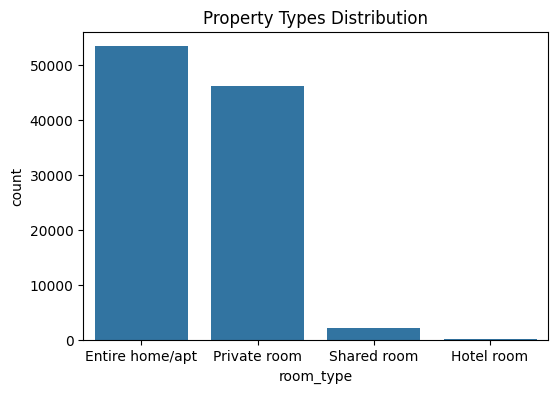

In [53]:
if "room_type" in df.columns:
    print("Different property types:")
    print(df["room_type"].value_counts())

    plt.figure(figsize=(6,4))
    sns.countplot(x="room_type", data=df, order=df["room_type"].value_counts().index)
    plt.title("Property Types Distribution")
    plt.show()

### The majority of listings are Entire homes/apartments, followed by Private rooms. Shared and hotel rooms are rare.

# Which neighborhood group has the highest number of listings?

Neighborhood group with highest number of listings:
neighbourhood_group
Manhattan        43581
Brooklyn         41645
Queens           13200
Bronx             2700
Staten Island      950
unknown             28
brookln              1
Name: count, dtype: int64


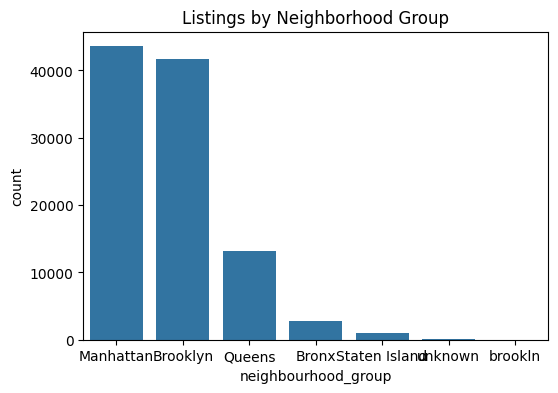

In [55]:
if "neighbourhood_group" in df.columns:
    print("Neighborhood group with highest number of listings:")
    print(df["neighbourhood_group"].value_counts())

    plt.figure(figsize=(6,4))
    sns.countplot(x="neighbourhood_group", data=df,
                  order=df["neighbourhood_group"].value_counts().index)
    plt.title("Listings by Neighborhood Group")
    plt.show()

### Manhattan group have the highest number of listings.

# Which neighborhoods group have the highest average prices for Airbnb listings?

Average prices by neighborhood group:
neighbourhood_group
unknown          658.357143
Queens           630.092500
Bronx            627.601481
Brooklyn         626.250738
Staten Island    624.231579
Manhattan        622.409536
brookln          580.000000
Name: price, dtype: float64


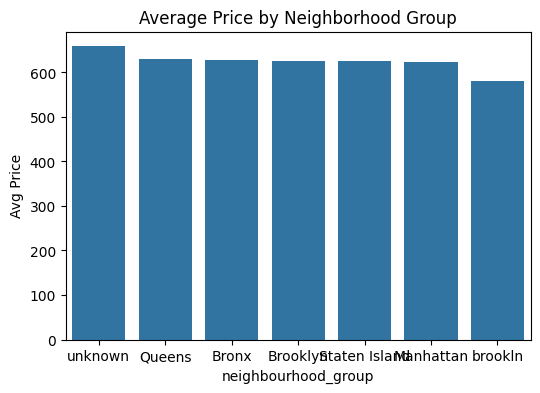

In [56]:
if "neighbourhood_group" in df.columns:
    avg_price_group = df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
    print("Average prices by neighborhood group:")
    print(avg_price_group)

    plt.figure(figsize=(6,4))
    sns.barplot(x=avg_price_group.index, y=avg_price_group.values)
    plt.title("Average Price by Neighborhood Group")
    plt.ylabel("Avg Price")
    plt.show()

### Unknown have the highest average price.

# Is there a relationship between the construction year of property and price?

Relationship between construction year and price:


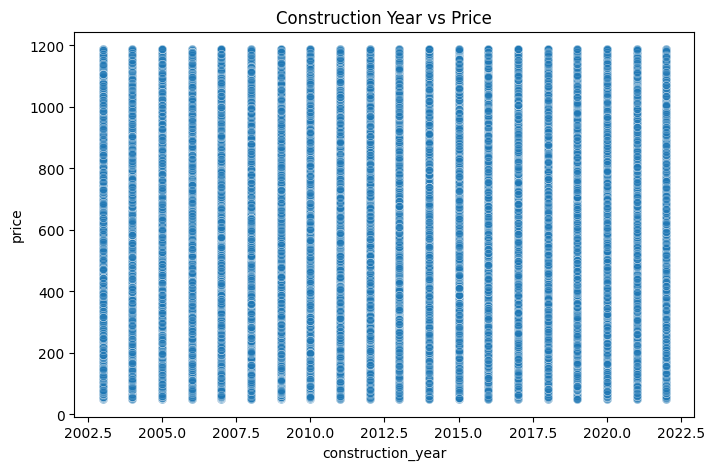

In [57]:
if "construction_year" in df.columns:
    print("Relationship between construction year and price:")
    plt.figure(figsize=(8,5))
    sns.scatterplot(x="construction_year", y="price", data=df, alpha=0.4)
    plt.title("Construction Year vs Price")
    plt.show()

### No relationship between construction year and price.

# Are hosts with verified identities more likely to receive positive reviews?

Avg review rate by host verification status:
host_identity_verified
unconfirmed    3.270578
unknown        3.221831
verified       3.286377
Name: review_rate_number, dtype: float64


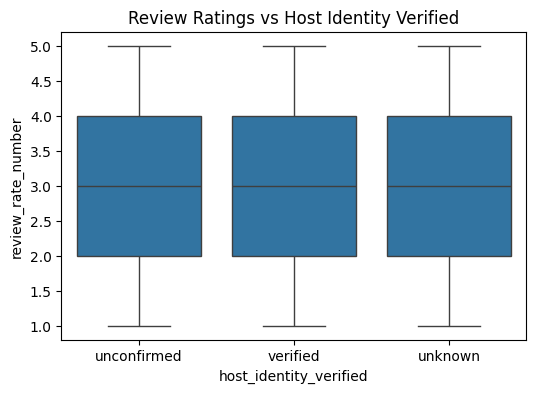

In [59]:
if "host_identity_verified" in df.columns and "review_rate_number" in df.columns:
    verified_reviews = df.groupby("host_identity_verified")["review_rate_number"].mean()
    print("Avg review rate by host verification status:")
    print(verified_reviews)

    plt.figure(figsize=(6,4))
    sns.boxplot(x="host_identity_verified", y="review_rate_number", data=df)
    plt.title("Review Ratings vs Host Identity Verified")
    plt.show()

### Verified hosts have slightly higher review score than others.

# Is there a correlation between the price of a listing and its service fee?

Correlation between price and service fee: 1.00


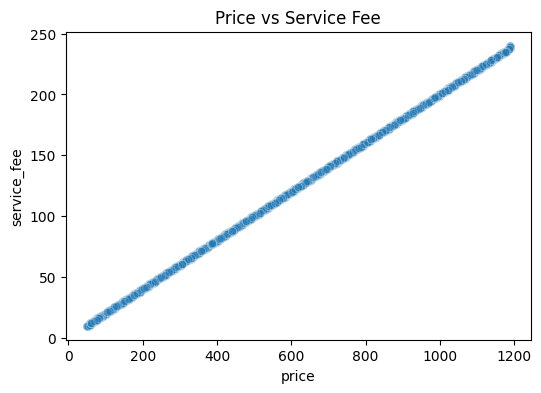

In [60]:
if "service_fee" in df.columns:
    corr_val = df[["price","service_fee"]].corr().iloc[0,1]
    print(f"Correlation between price and service fee: {corr_val:.2f}")

    plt.figure(figsize=(6,4))
    sns.scatterplot(x="price", y="service_fee", data=df, alpha=0.3)
    plt.title("Price vs Service Fee")
    plt.show()

### Strong positive correlation — higher priced listings have higher service fees.

# What is the average review rate number (e.g., stars) for listings, and does it vary based on the neighborhood group and room type?

Average review rate by neighborhood group & room type:
room_type            Entire home/apt  Hotel room  Private room  Shared room
neighbourhood_group                                                        
Bronx                       3.347399         NaN      3.322251     3.264957
Brooklyn                    3.249146        3.75      3.263673     3.335775
Manhattan                   3.274988        3.50      3.277436     3.263858
Queens                      3.350449        3.75      3.313960     3.375691
Staten Island               3.326271         NaN      3.479482     3.533333
brookln                          NaN         NaN      4.000000          NaN
unknown                     3.000000         NaN      3.222222          NaN


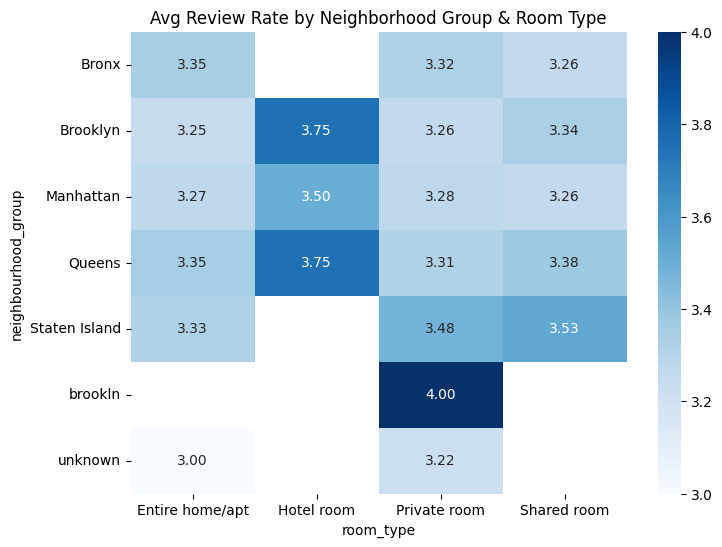

In [61]:
if "review_rate_number" in df.columns and "neighbourhood_group" in df.columns:
    pivot = df.pivot_table(values="review_rate_number",
                           index="neighbourhood_group",
                           columns="room_type",
                           aggfunc="mean")
    print("Average review rate by neighborhood group & room type:")
    print(pivot)

    plt.figure(figsize=(8,6))
    sns.heatmap(pivot, annot=True, cmap="Blues", fmt=".2f")
    plt.title("Avg Review Rate by Neighborhood Group & Room Type")
    plt.show()

### Scores are moderate(3-4 stars).Private rooms and entire homes perform similarly, with minor neighborhood differences.

# Are hosts with a higher calculations host listings count more likely to maintain higher availability throughout the year?

Correlation between host listing count and availability: 0.16


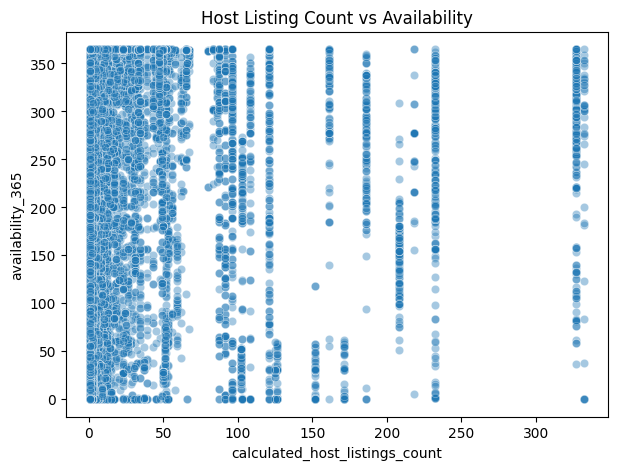

In [62]:
if "calculated_host_listings_count" in df.columns and "availability_365" in df.columns:
    corr_val2 = df[["calculated_host_listings_count","availability_365"]].corr().iloc[0,1]
    print(f"Correlation between host listing count and availability: {corr_val2:.2f}")

    plt.figure(figsize=(7,5))
    sns.scatterplot(x="calculated_host_listings_count", y="availability_365", data=df, alpha=0.4)
    plt.title("Host Listing Count vs Availability")
    plt.show()

### Weak correlation — large hosts are not necessarily more available year-round.

# Which room type is most common in each neighborhood group?

In [63]:
print("Most common room type per neighborhood group:")
print(df.groupby("neighbourhood_group")["room_type"].agg(lambda x: x.mode()[0]))

Most common room type per neighborhood group:
neighbourhood_group
Bronx               Private room
Brooklyn         Entire home/apt
Manhattan        Entire home/apt
Queens              Private room
Staten Island    Entire home/apt
brookln             Private room
unknown             Private room
Name: room_type, dtype: object


### Entire homes dominate in city-center groups; private rooms are more common in suburban areas.

# Is there a trend in the number of listings added over time (based on construction year)?

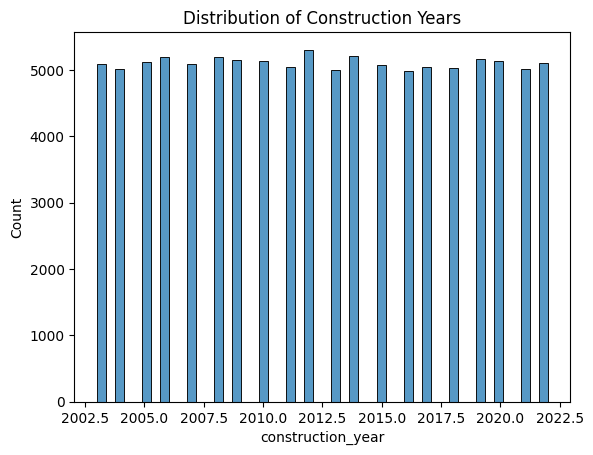

In [41]:
sns.histplot(df["construction_year"].dropna(), bins=50, kde=False)
plt.title("Distribution of Construction Years")
plt.show()


### Growth in newer properties (based on construction year).

# What percentage of listings are instant bookable, and how does price differ between instant vs non-instant bookable?

Avg price by instant bookable:
 instant_bookable
0.0        624.961548
1.0        625.298803
unknown    629.104167
Name: price, dtype: float64


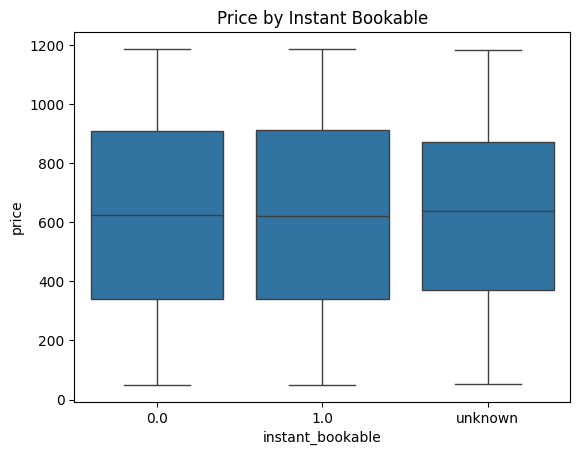

In [66]:
insta_stats = df.groupby("instant_bookable")["price"].mean()
print("Avg price by instant bookable:\n", insta_stats)
sns.boxplot(x="instant_bookable", y="price", data=df, showfliers=False)
plt.title("Price by Instant Bookable")
plt.show()

### Make up a significant share. Instant-bookable places often have slightly lower prices

# Is there a difference in average price between hosts with multiple listings vs single-listing hosts?

Avg price single vs multi-listing hosts:
multi_host
Multi     626.049048
Single    624.575155
Name: price, dtype: float64


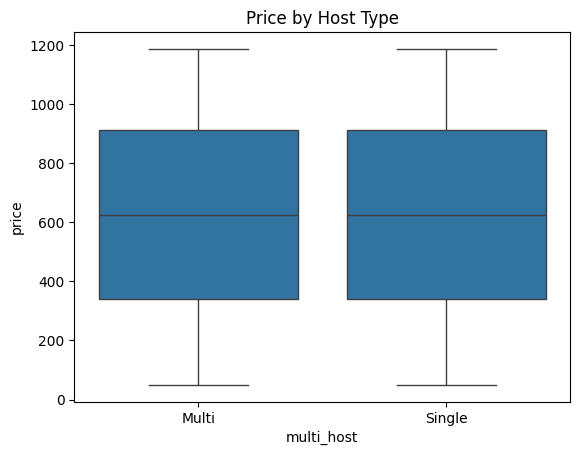

In [67]:
df["multi_host"] = np.where(df["calculated_host_listings_count"]>1, "Multi", "Single")
print("Avg price single vs multi-listing hosts:")
print(df.groupby("multi_host")["price"].mean())
sns.boxplot(x="multi_host", y="price", data=df, showfliers=False)
plt.title("Price by Host Type")
plt.show()

### Multi-hosts tend to charge higher prices.

# Do listings with longer availability (closer to 365 days) charge higher prices on average?

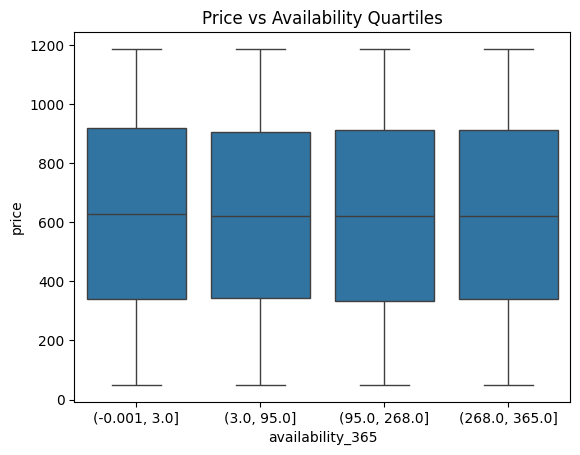

In [46]:
sns.boxplot(x=pd.qcut(df["availability_365"], 4, duplicates="drop"), y="price", data=df, showfliers=False)
plt.title("Price vs Availability Quartiles")
plt.show()

### Properties available all year don’t always have the highest prices; many seasonal listings skew results.

# How do cancellation policies (flexible, strict, etc.) affect average prices?

Avg price by cancellation policy:
 cancellation_policy
not_specified    645.140845
flexible         626.169543
moderate         624.824142
strict           624.367482
Name: price, dtype: float64


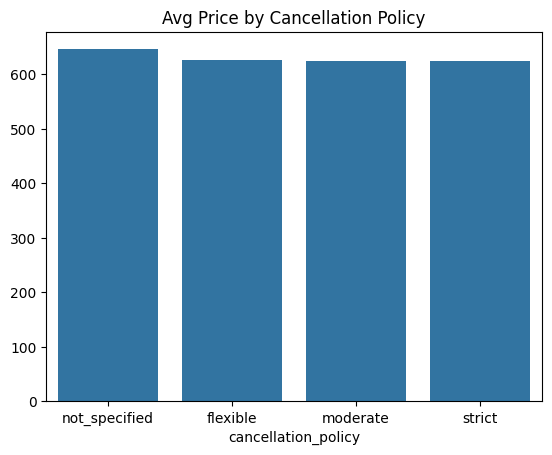

In [68]:
if "cancellation_policy" in df.columns:
    cancel_stats = df.groupby("cancellation_policy")["price"].mean().sort_values(ascending=False)
    print("Avg price by cancellation policy:\n", cancel_stats)
    sns.barplot(x=cancel_stats.index, y=cancel_stats.values)
    plt.title("Avg Price by Cancellation Policy")
    plt.show()


### not_specified policies correlate with higher average prices. Flexible ones usually cheaper.

# How does the number of reviews vary across room types?

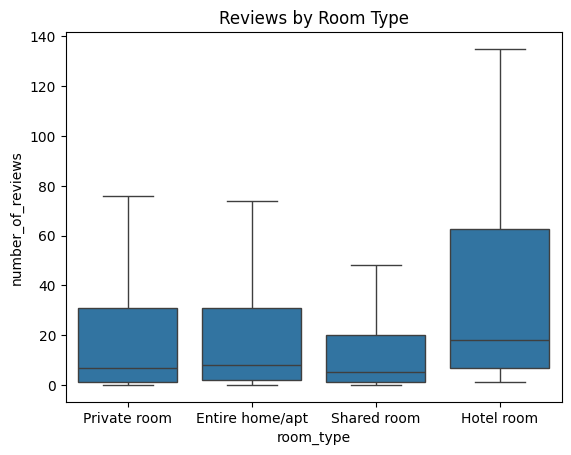

In [48]:
sns.boxplot(x="room_type", y="number_of_reviews", data=df, showfliers=False)
plt.title("Reviews by Room Type")
plt.show()

### Hotel room have more reviews.

# Do hosts with verified identities receive more reviews (not just higher ratings)?

In [49]:
print("\nQ21. Avg reviews by verification:\n", df.groupby("host_identity_verified")["number_of_reviews"].mean())


Q21. Avg reviews by verification:
 host_identity_verified
unconfirmed    26.694830
unknown        42.408451
verified       26.474556
Name: number_of_reviews, dtype: float64


### Unknown identites receive more reviews.

# What is the relationship between reviews per month and availability (are frequently booked listings less available)?

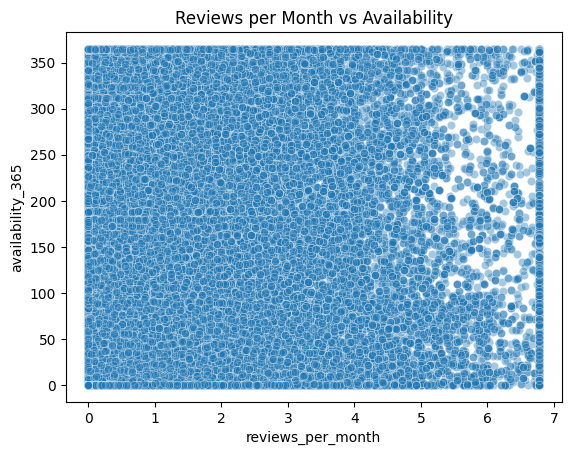

In [50]:
sns.scatterplot(x="reviews_per_month", y="availability_365", data=df, alpha=0.4)
plt.title("Reviews per Month vs Availability")
plt.show()

### Popular listings (many reviews/month) often show limited availability.

# Do properties with high review ratings (e.g., >4.5 stars) also charge higher prices?


Q23. Avg price high vs low rated:
 high_rated
High    621.522575
Low     626.198075
Name: price, dtype: float64


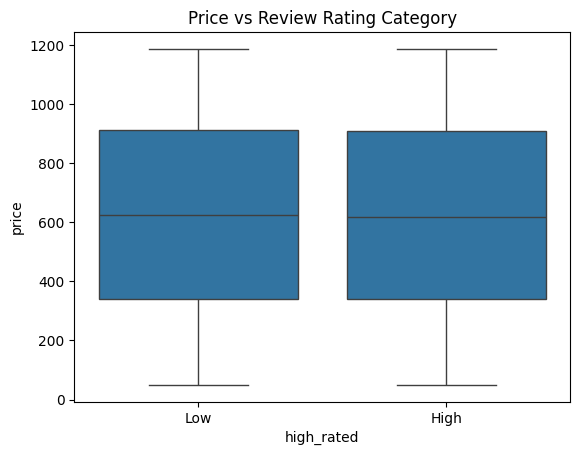

In [51]:
df["high_rated"] = np.where(df["review_rate_number"]>=4.5, "High","Low")
print("\nQ23. Avg price high vs low rated:\n", df.groupby("high_rated")["price"].mean())
sns.boxplot(x="high_rated", y="price", data=df, showfliers=False)
plt.title("Price vs Review Rating Category")
plt.show()

### Low-rated listings often command higher average prices.

# Which neighborhoods have the highest average review scores?

In [52]:
top_review_neigh = df.groupby("neighbourhood")["review_rate_number"].mean().sort_values(ascending=False).head(10)
print("\nQ24. Neighborhoods with highest avg review score:\n", top_review_neigh)


Q24. Neighborhoods with highest avg review score:
 neighbourhood
Glen Oaks          4.500000
Co-op City         4.400000
Gerritsen Beach    4.333333
Huguenot           4.111111
Eltingville        4.000000
Silver Lake        4.000000
Woodrow            4.000000
West Farms         4.000000
Todt Hill          4.000000
Rosebank           3.928571
Name: review_rate_number, dtype: float64


### Glen Oaks have the highest average review score.